# Logistic regression

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand logistic regression;
- Understand the differences between logistic regression and linear discriminant analysis;
- Understand the probablistic output of logistic regression.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
from pathlib import Path
import pickle
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Exercise 1: Optimization function of logistic regression

The following cost function for logistic regression needs to get minimized to determine the optimal choice of the parameters $\mathbf{w}$:

\begin{equation}
J_{1}(w) = \sum_{i=1}^{N_{samples}} \ln(\exp(-\mathbf{y_{i}}(\mathbf{w}^{\rm T}\mathbf{x_{i}}))+1)
\end{equation}

Assuming linear separability of a given data set, what can happen to the weights $\mathbf w$ when minimizing the cost function $J_{1}(\mathbf{w})$? Why is this a problem? 

**Hint:** Assume there exists a weight vector $\mathbf{\tilde w}$ such that $\mathbf{y_{i}}(\mathbf{\tilde w}^{\rm T}\mathbf{x_{i}}) > 0$ for all sample points $i$. The class labels are defined as $y_{i}=\{-1,1\}$.

**Hint:** Plot this function to get an intuition for what this function looks like.

By minimizing the cost function J1(w), it will go towards 0, but does not attain a finite w. This makes the gradient descent always increase its weight norm. Causing vanishing gradients and no unique solution.

## Exercise 2: Adding regularization

A more stable estimate for $\mathbf{w}$ can be achieved when using the concept of **regularization**. Adding an additional term $J_{2}(\mathbf{w}) = \frac{1}{2}\mathbf{w}^{\rm T}\mathbf{w}$ to the cost function modifies the overall cost function $J(\mathbf{w},C)$ to: 

\begin{equation}
J(w,C) = J_{1}(\mathbf{w},C) + J_{2}(\mathbf{w}) = C\cdot \sum_{i=1}^{N_{samples}} \ln(\exp(-\mathbf{y}(\mathbf{w}^{\rm T}\mathbf{X}))+1) + \frac{1}{2}\mathbf{w}^{\rm T}\mathbf{w}
\end{equation}

Note, that the so-called regularization parameter $C$ determines the relation of the second cost function $J_{2}(w)$ with respect to the first cost function $J_{1}(w)$.

Which role has the additional cost function $J_{2}(w)$?

J2(w) balances out a weight explosion by making a quadratic penalty. This removes the posibility of w approaching infinite. It also controls the complexity and acts as shrinkage, making the less important value even lower so it does not infere with our data.

## Exercise 3: Evaluate and visualize the output of a logistic regression model
Below we provide a dataset for this exercise. 
1. Visualize the given training data set using the class labels. 
2. Lookup the scikit-learn toolbox implementation of a Logistic Regression model. Then train a model on the given training data. Please make sure that you use an "L2-penalty" for regularization and set your regularization parameter to C = 1.
3. Use your trained Logistic Regression model to predict the class labels of the test data and report on the classification performance.
4. Inspect the given function `plot_probabilityMap` and use it to visualize the probability map of class "1" of your trained Logistic Regression model using the test data set as an input.

In [2]:
from sklearn.metrics import accuracy_score

ds_trainData = 'data/spread_train.data'
ds_trainLabels ='data/spread_train.labels'
ds_testData = 'data/spread_test.data'
ds_testLabels ='data/spread_test.labels'

# load training data
X_train = np.loadtxt(ds_trainData)
y_train = np.loadtxt(ds_trainLabels)

# load test data
X_test = np.loadtxt(ds_testData)
y_test = np.loadtxt(ds_testLabels)

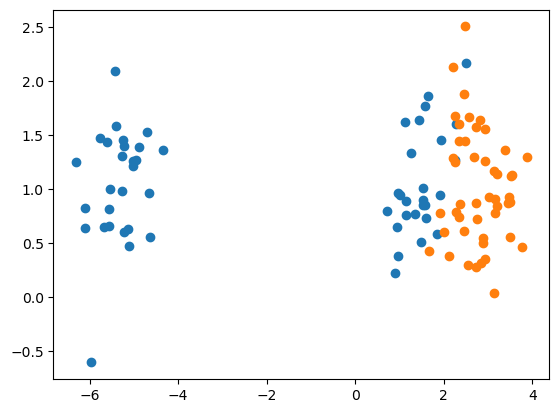

In [3]:
def plot_probabilityMap(model, X, y, yh, plot_means, class_index):
    '''visualizes the output of the applied models with a probability map
    INPUT: 
        'model'-> scikit-learn like instance of classifier models with built-in method 'predict_proba' available
        'X' -> data matrix of size NxD
        'y' -> true class labels
        'yh' -> predicted class labels
        'plot_means' -> only for LDA: adding class means to the plot
        'class_index' -> probability map for class, either '0' or '1'
    
    OUTPUT:
        fig: figure handle of the plot
    '''
    fig = plt.figure(figsize=(8, 4))
    
    tp = (y == yh)  # True Positive
    tp0, tp1 = tp[y == 0], tp[y == 1]
    X0, X1 = X[y == 0], X[y == 1]
    X0_tp, X0_fp = X0[tp0, :], X0[~tp0, :]
    X1_tp, X1_fp = X1[tp1, :], X1[~tp1, :]

    # class 0: true positives vs. false positives
    plt.plot(X0_tp[:, 0], X0_tp[:, 1], 'o', color='red', label="class 0 tp")
    plt.plot(X0_fp[:, 0], X0_fp[:, 1], 'o', color='salmon', label="class 0 fp")  # dark red

    # class 1:
    plt.plot(X1_tp[:, 0], X1_tp[:, 1], 'o', color='blue', label="class 1 tp")
    plt.plot(X1_fp[:, 0], X1_fp[:, 1], 'o', color='lightskyblue', label="class 1 fp")  # dark blue

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    
    # class 0 and 1 : areas
    nx, ny = 200, 100
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, class_index].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap='YlOrBr', shading='auto')
    cbar = plt.colorbar()  # colorbar assigning the probabilities
    cbar.set_label('P(class={})'.format(class_index))
        
    # plot the contour of the 50 probability
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='k')

    # plot class means (only makes sense for LDA)
    if plot_means: 
        plt.plot(model.means_[0][0], model.means_[0][1], 'o', color='black', markersize=10)
        plt.plot(model.means_[1][0], model.means_[1][1], 'o', color='black', markersize=10)

    return fig

plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1])
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1])
plt.show()

0.89


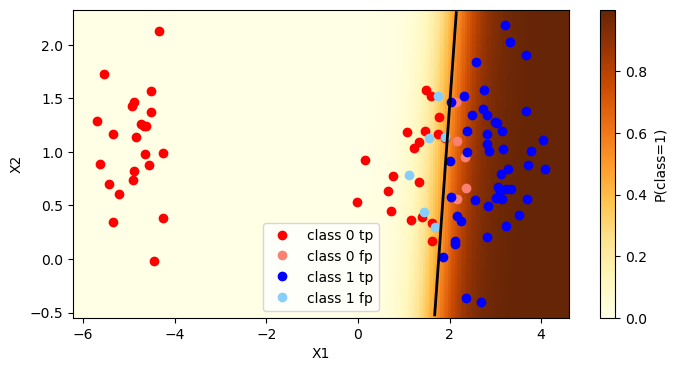

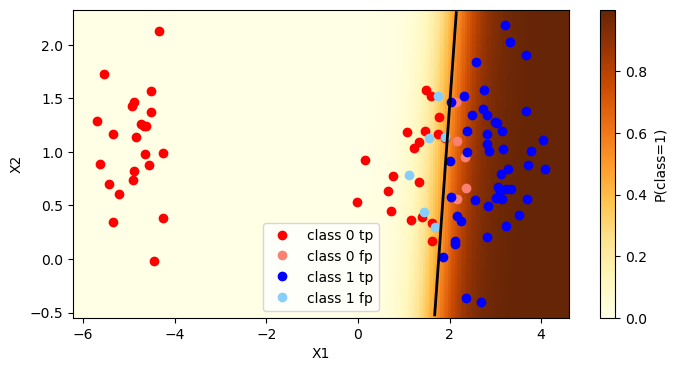

In [4]:
model = LogisticRegression(penalty="l2", C=1.0).fit(X_train,y_train)
y_pred = model.predict(X_test)

# Accuracy is calculatable without importing but for simplicity we used accuracy_score from sklearn.metrics
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


plot_probabilityMap(model, X_test, y_test, y_pred, 0, 1)

## (Optional) Exercise 4: Comparison with performance of the LDA 

For comparison, you now need to train and evaluate an LDA model on the same data set and evaluate its performance.

1. Lookup the scikit-learn toolbox implementation for an LDA model. Then train a model on the given training data. Please specify your solver to "eigen".
2. Use your trained LDA model to predict the class labels of the test data and report on the classification performance.
3. Apply the given function `plot_probabilityMap` to visualize the probability map of class "1" of your trained LDA model taking the test data set as an input. Use the input parameter of the function to visualize the class means.
4. Compare the performance of the logistic regression model with the LDA model for the given dataset. Do you observe a severe difference in the performance of both models? Can you explain the reason? **Hint:** You can compare the two decision boundaries and the assumptions made by the methods.
5. How can you estimate a probability from an LDA classifier? Remember that this is not a probabilistic method by default.

0.78


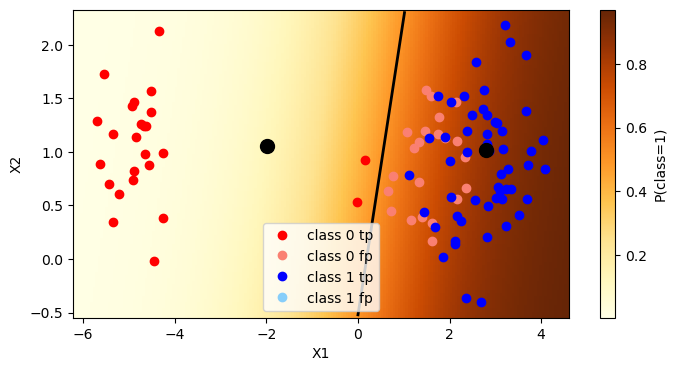

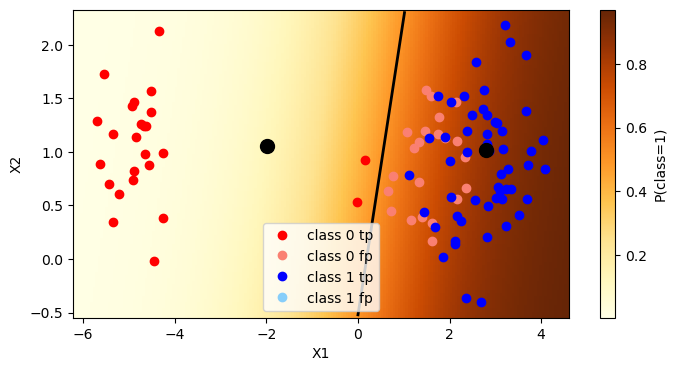

In [5]:
model = LinearDiscriminantAnalysis(solver="eigen").fit(X_train,y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


plot_probabilityMap(model, X_test, y_test, y_pred, 1, 1)

LDA calculates the probabilty using gaussian likelyhoods and bayes' rule

## Exercise 5: From classification results to BCI
In a real world BCI application, classification of a single event might you be an auxiliary step towards establishing a BCI control. Imagine a P300 speller in which you would perform a classification of each flashed image to `target` or `non-target`. In order to be able to spell with such a stimulus + decoding approach, you would still interpret a pooled set of classification results.

In this exercise, you will perform this last interpretation step to work from single trial classification results towards an usefull interpretation for a user interacting with such a BCI system. You are given a model trained on a real persons EEG data as well as a simulation generator which will provide simulated EEG data for `target` and `non-target` epochs parametriced to the same person.

**Question**: 
1. What would be the sentence that can be decoded with the given model?
2. How could you improve the decoding accuracy in this simulation? Please describe or implement.

In [6]:
# Given speller setup and pre-trained model

# Simulated speller data
characters_matrix = np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567|~_')).reshape(6,6)
print('The BCI characters matrix:\n', characters_matrix)
target = 'BB|~BB_IS_THE_QUESTION'

# Load some parameters resulting from a real subjects decoding
p = Path.cwd().joinpath('data', 'simulation_parameters.pickle')
d = pickle.load(open(p,'rb'))
means_target = d['mean_Target']
means_non_target = d['mean_Nontarget']
cov = d['cov']

def sample_one_simulated_trial(char, highlighted,
                               means_target=means_target,
                               means_non_target=means_non_target,
                               cov=cov):  
    if char in highlighted:
        X = np.random.multivariate_normal(means_target, cov)
    else:
        X = np.random.multivariate_normal(means_non_target, cov)
    return X

# query for EEG data
def get_target_online_generator(target=target, n_reps=5):
    """ A generator function simulating a real online BCI data acquisition """
    i = 0
    while True and i < len(target):
        # print('>>> NEXT CHARACTER')
        char = target[i]
        # print(f'"I am focussing on character [{char}]" - {i=}')
        
        # Assume a very simple way of speller were we iterate over the rows and
        # over the columns 5 times
        for j in range(n_reps):
            for row in characters_matrix:
                yield sample_one_simulated_trial(char, row)
            for col in characters_matrix.T:
                yield sample_one_simulated_trial(char, col)
        i += 1

# load the classifier from wherever you stored the axiliary data
lda = joblib.load('./data/lda_subj2_slow.joblib')

The BCI characters matrix:
 [['A' 'B' 'C' 'D' 'E' 'F']
 ['G' 'H' 'I' 'J' 'K' 'L']
 ['M' 'N' 'O' 'P' 'Q' 'R']
 ['S' 'T' 'U' 'V' 'W' 'X']
 ['Y' 'Z' '1' '2' '3' '4']
 ['5' '6' '7' '|' '~' '_']]


C:\Users\casva\anaconda3\Lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator LinearDiscriminantAnalysis from version 1.1.3 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# In a real world BCI, you would get the trials incoming one by one, knowing that
# the speller iterates over rows and columns <n_rep> times, derive the spelled characters

# YOUR IMPLEMENTATION SHOULD COME HERE AND INCLUDE THE FOLLOWING
# Solution - BCI Implementation:
decoded_characters = []

n_rep = 5 
nrows = characters_matrix.shape[0]
ncols = characters_matrix.shape[1]
gen = get_target_online_generator(n_reps=n_rep)

for i, trial_data in enumerate(gen):
    pass

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here